In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [5]:
N_arr = [2, 5, 10, 20, 30, 40, 50, 100]
N_tabdiff_arr = [2, 5, 10, 20, 30, 40, 50, 100]

In [6]:
path_tabdiff = '/home/okashurin/okashurin/TabDiff/eval/report_runs/try_1/'
path_vddpm = '/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.1_decay_xt_t_variational'

In [7]:
def get_data(path, N_arr):
    shape_arr = []
    trend_arr = []
    mle_arr = []
    c2st_arr = []

    std_shape_arr = []
    std_trend_arr = []
    std_mle_arr = []
    std_c2st_arr = []

    for i in range(len(N_arr)):
        N = N_arr[i]

        df_path = os.path.join(path, f'N_{N}/adult/avg_std.csv')
        df = pd.read_csv(df_path, skiprows=1, header=None)

        shape_arr.append(df.iloc[0, 1])
        trend_arr.append(df.iloc[1, 1])
        mle_arr.append(df.iloc[2, 1])
        c2st_arr.append(df.iloc[3, 1])

        std_shape_arr.append(df.iloc[0, 2])
        std_trend_arr.append(df.iloc[1, 2])
        std_mle_arr.append(df.iloc[2, 2])
        std_c2st_arr.append(df.iloc[3, 2])

    shape_arr = np.array(shape_arr)
    trend_arr = np.array(trend_arr)
    mle_arr = np.array(mle_arr)
    c2st_arr = np.array(c2st_arr)

    std_shape_arr = np.array(std_shape_arr)
    std_trend_arr = np.array(std_trend_arr)
    std_mle_arr = np.array(std_mle_arr)
    std_c2st_arr = np.array(std_c2st_arr)

    return {
        'shape': shape_arr,
        'trend': trend_arr,
        'mle': mle_arr,
        'c2st': c2st_arr,
        'std_shape': std_shape_arr,
        'std_trend': std_trend_arr,
        'std_mle': std_mle_arr,
        'std_c2st': std_c2st_arr
    }

In [8]:
data_tabdiff = get_data(path_tabdiff, N_tabdiff_arr)
data_vddpm = get_data(path_vddpm, N_arr)

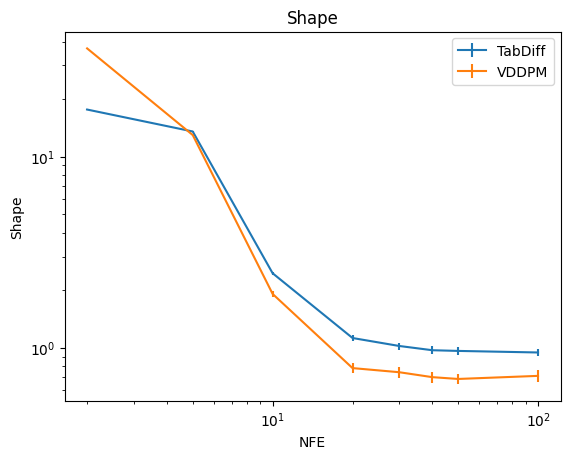

In [9]:
plt.errorbar(N_tabdiff_arr, data_tabdiff['shape'], yerr=data_tabdiff['std_shape'], label='TabDiff')
plt.errorbar(N_arr, data_vddpm['shape'], yerr=data_vddpm['std_shape'], label='VDDPM')
plt.title('Shape')
plt.xlabel('NFE')
plt.ylabel('Shape')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

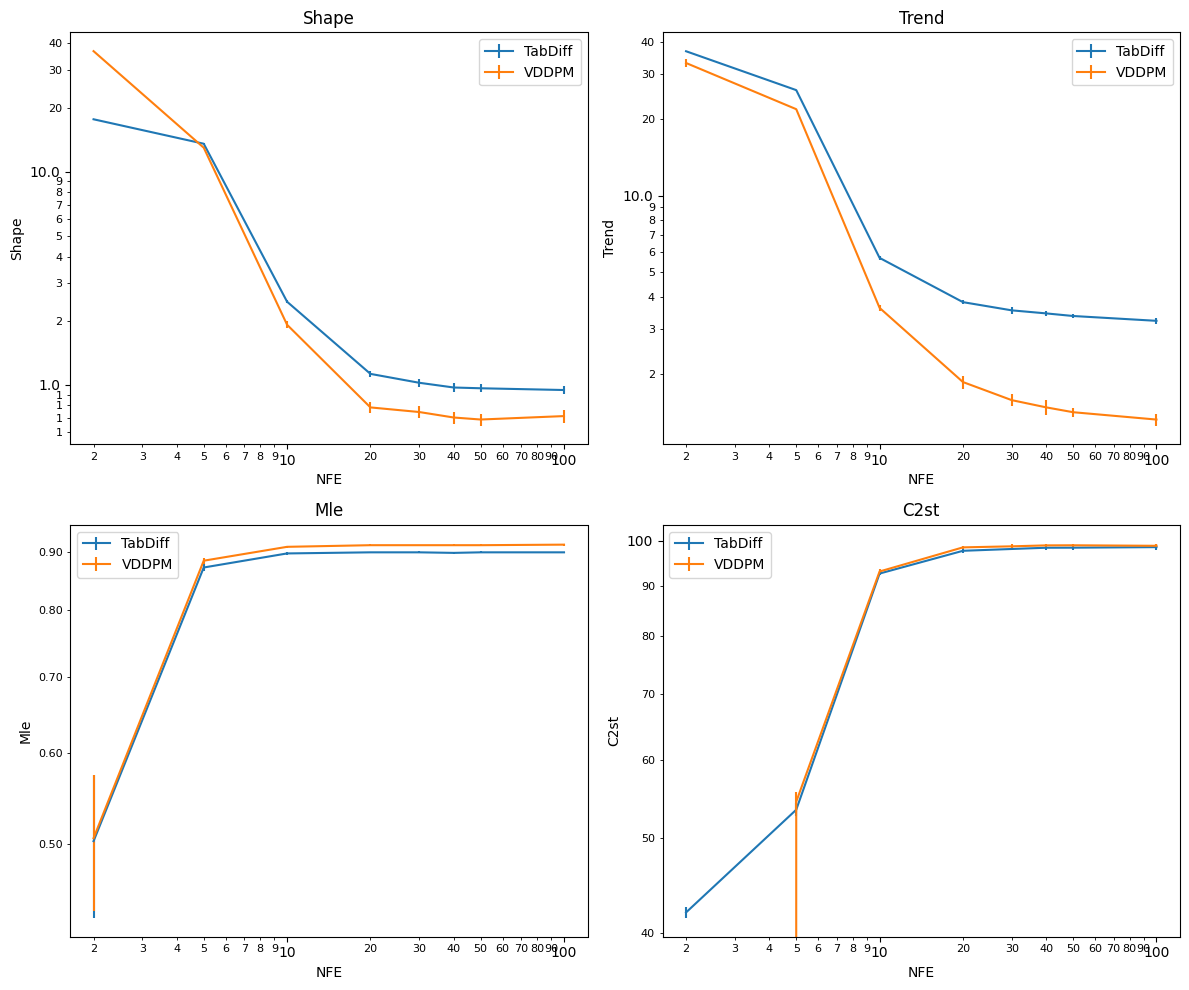

In [10]:
from matplotlib.ticker import LogLocator, ScalarFormatter

metrics = ['shape', 'trend', 'mle', 'c2st']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (ax, metric) in enumerate(zip(axes, metrics)):
    ax.errorbar(
        N_tabdiff_arr,
        data_tabdiff[metric],
        yerr=data_tabdiff[f'std_{metric}'],
        label='TabDiff'
    )
    ax.errorbar(
        N_arr,
        data_vddpm[metric],
        yerr=data_vddpm[f'std_{metric}'],
        label='VDDPM'
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel('NFE')
    ax.set_ylabel(metric.capitalize())

    ax.set_xscale('log')
    ax.set_yscale('log')

    # major + minor tick locations
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(2, 10)))

    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=range(2, 10)))

    # standard number formatting instead of scientific notation
    xfmt = ScalarFormatter()
    xfmt.set_scientific(False)
    xfmt.set_useOffset(False)

    yfmt = ScalarFormatter()
    yfmt.set_scientific(False)
    yfmt.set_useOffset(False)

    ax.xaxis.set_major_formatter(xfmt)
    ax.xaxis.set_minor_formatter(xfmt)
    ax.yaxis.set_major_formatter(yfmt)
    ax.yaxis.set_minor_formatter(yfmt)

    # show minor tick labels
    ax.tick_params(axis='both', which='minor', labelsize=8)
    ax.tick_params(axis='both', which='major', labelsize=10)

    ax.legend()

plt.tight_layout()
plt.show()